## Problem Statement

In the highly competitive taxi booking industry, maximizing driver revenue is essential for operational sustainability and customer satisfaction. Taxi companies process millions of rides daily, generating large volumes of transactional data that can reveal important behavioral patterns.

One critical business question is whether a passenger’s payment method influences the fare amount and overall revenue generated per trip. Understanding this relationship can help taxi companies optimize payment strategies, improve driver incentives, and design targeted promotional campaigns.

This project uses statistical hypothesis testing and exploratory data analysis to investigate whether there is a statistically significant difference in fare amounts between customers who pay using credit cards and those who pay using cash.

Using Python, data cleaning, visualization, and inferential statistics, this project transforms raw taxi trip records into actionable business insights.

## Research Question
### Primary Research Question

Does the passenger payment method significantly affect taxi fare amount?

### Statistical Research Question

**Null Hypothesis (H₀):**
There is no significant difference in average fare amount between payment methods. This means the average (mean) values for credit card and cash payments are equal.

$$
H_0: \mu_{\text{credit card}} = \mu_{\text{cash}}
$$


**Alternative Hypothesis (H₁):**

$$
H_1: \mu_{\text{credit card}} \ne \mu_{\text{cash}}
$$

This means there is a statistically significant difference in the average fare amount between credit card and cash payment methods.

## Business Objective
- Identify which payment method generates higher average revenue
- Help taxi companies optimize payment strategies
- Provide data-driven recommendations for driver earnings improvement
- Demonstrate the practical use of A/B testing in transportation analytics

## Project Agenda
1. Business Understanding
- Understand the taxi revenue problem
- Define research objectives
2. Data Collection
- Import NYC taxi trip dataset
3. Data Cleaning
- Remove irrelevant columns
- Handle missing values
- Remove outliers
- Filter invalid fares
4. Exploratory Data Analysis (EDA)
- Analyze payment type distribution
- Compare fare distributions
- Visualize customer behavior
5. Statistical Hypothesis Testing
- Perform independent two-sample t-test
- Evaluate p-value
- Interpret statistical significance
6. Business Insights
- Identify high-value payment methods
- Revenue optimization recommendations
7. Conclusion
- Summarize findings
- Discuss limitations and future improvements

## Import Libraries

In [126]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from scipy.stats import ttest_ind
import statsmodels.api as sm

ModuleNotFoundError: No module named 'scipy.signal'

## Load Dataset

In [3]:
# Get list of all parquet files
parquet_files = glob.glob('*.parquet')
# Read all into a list, then concat
df = pd.concat([pd.read_parquet(f) for f in parquet_files], ignore_index=True)

In [4]:
df.shape

(11077206, 20)

In [5]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


## Data Preparing and Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11077206 entries, 0 to 11077205
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee         

In [8]:
df['duration' ] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df['duration'] = df['duration'].dt.total_seconds()/60
df.head(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00,5.550000
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75,5.716667


In [9]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee', 'duration'],
      dtype='object')

#### Keep only the required columns

In [70]:
required_columns = ['payment_type','passenger_count', 'trip_distance', 'fare_amount','duration']
data = df[required_columns]
data.head()

,payment_type,passenger_count,trip_distance,fare_amount,duration
0,1,1.0,0.97,7.2,5.550000
1,2,0.0,0.90,7.9,5.716667
2,1,0.0,1.40,10.7,8.883333
3,1,4.0,5.58,38.7,42.800000
4,1,0.0,2.16,13.5,13.500000


#### Handle Missing Values

In [71]:
data.isnull().sum()

payment_type             0
passenger_count    3057123
trip_distance            0
fare_amount              0
duration                 0
dtype: int64

In [72]:
data.isnull().sum()/len(df)

payment_type       0.000000
passenger_count    0.275983
trip_distance      0.000000
fare_amount        0.000000
duration           0.000000
dtype: float64

In [73]:
data.dropna(inplace = True)
data.shape

(8020083, 5)

In [74]:
data.head()

,payment_type,passenger_count,trip_distance,fare_amount,duration
0,1,1.0,0.97,7.2,5.550000
1,2,0.0,0.90,7.9,5.716667
2,1,0.0,1.40,10.7,8.883333
3,1,4.0,5.58,38.7,42.800000
4,1,0.0,2.16,13.5,13.500000


In [75]:
data['passenger_count'] = data['passenger_count'].astype('int16')
data.dtypes

payment_type         int64
passenger_count      int16
trip_distance      float64
fare_amount        float64
duration           float64
dtype: object

In [76]:
data[data.duplicated()].shape

(4209745, 5)

In [77]:
data.drop_duplicates(inplace= True)
data.shape

(3810338, 5)

#### Understand Payment Type Encoding

Usually:

1 = Credit Card; </br>
2 = Cash

In [78]:
data['payment_type'].value_counts(normalize= True)

payment_type
1    0.791883
2    0.170434
4    0.029352
3    0.008331
Name: proportion, dtype: float64

In [79]:
# Keep Only Credit Card and Cash Payments
data = data[data['payment_type'].isin([1,2])]
data.shape

(3666753, 5)

In [80]:
# Rename Payment Categories
data['payment_type'] = data['payment_type'].replace({1: 'Card', 2:'Cash'})
data.head()

,payment_type,passenger_count,trip_distance,fare_amount,duration
0,Card,1,0.97,7.2,5.550000
1,Cash,0,0.90,7.9,5.716667
2,Card,0,1.40,10.7,8.883333
3,Card,4,5.58,38.7,42.800000
4,Card,0,2.16,13.5,13.500000


#### Clean Passenger count column

In [81]:
data['passenger_count'].value_counts(normalize= True)

passenger_count
1    7.277657e-01
2    1.738015e-01
3    4.738525e-02
4    3.200161e-02
0    8.541344e-03
5    6.687388e-03
6    3.813728e-03
8    2.181767e-06
9    8.181626e-07
7    5.454417e-07
Name: proportion, dtype: float64

Passenger counts outside the valid operational range (0 passengers and values greater than 5) are considered inconsistent with typical taxi trip constraints and are treated as invalid records. These entries should be removed to ensure the dataset reflects realistic trip conditions

In [82]:
data = data[(data['passenger_count']> 0) & (data['passenger_count'] < 6)].copy()
data.shape

(3621437, 5)

#### Remove negative or unrealistic values

In [83]:
data.describe()

,passenger_count,trip_distance,fare_amount,duration
count,3.621437e+06,3.621437e+06,3.621437e+06,3.621437e+06
mean,1.396223e+00,5.715904e+00,2.889825e+01,2.586161e+01
std,7.815703e-01,5.878359e+01,2.314927e+01,3.931570e+01
min,1.000000e+00,0.000000e+00,-2.084100e+03,-1.170000e+01
25%,1.000000e+00,1.700000e+00,1.420000e+01,1.268333e+01
50%,1.000000e+00,3.300000e+00,2.190000e+01,2.035000e+01
75%,2.000000e+00,8.100000e+00,3.730000e+01,3.153333e+01
max,5.000000e+00,9.877358e+04,2.084100e+03,9.265150e+03


The presence of negative values in fare amount, tip amount, total amount, and trip duration  indicates invalid or inconsistent records that are not meaningful in the context of taxi trip transactions.  These observations should be removed to ensure data quality and preserve the validity of subsequent statistical analysis.

In [84]:
data = data[data['fare_amount'] > 0]
data = data[data['duration'] > 0]
data.describe()

,passenger_count,trip_distance,fare_amount,duration
count,3.566909e+06,3.566909e+06,3.566909e+06,3.566909e+06
mean,1.395802e+00,5.731117e+00,2.920241e+01,2.615415e+01
std,7.817512e-01,5.922642e+01,2.270335e+01,3.936771e+01
min,1.000000e+00,0.000000e+00,1.000000e-02,1.666667e-02
25%,1.000000e+00,1.700000e+00,1.420000e+01,1.296667e+01
50%,1.000000e+00,3.300000e+00,2.250000e+01,2.055000e+01
75%,2.000000e+00,8.110000e+00,3.730000e+01,3.175000e+01
max,5.000000e+00,9.877358e+04,2.084100e+03,9.265150e+03


#### Outlier Treatment

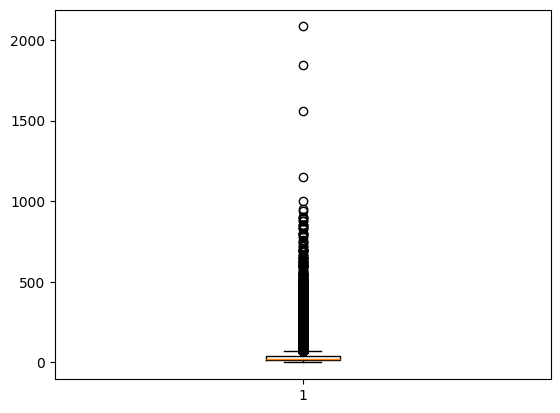

In [85]:
plt.boxplot(data['fare_amount'])
plt.show()

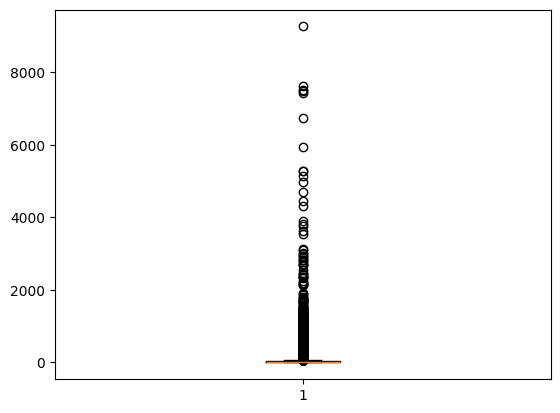

In [86]:
plt.boxplot(data['duration'])
plt.show()

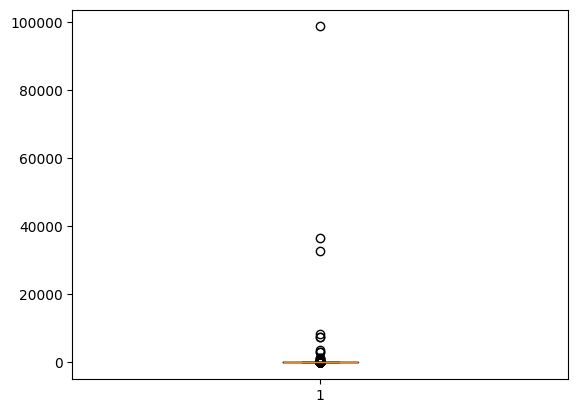

In [87]:
plt.boxplot(data['trip_distance'])
plt.show()

In [88]:
data.columns

Index(['payment_type', 'passenger_count', 'trip_distance', 'fare_amount',
       'duration'],
      dtype='object')

**Using IQR Method**

In [89]:
for col in ['trip_distance', 'fare_amount', 'duration']:
    Q1= data[col].quantile(0.25) 
    Q3= data[col].quantile(0.75)
    
    IQR = Q3-Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

In [90]:
data.describe()

,passenger_count,trip_distance,fare_amount,duration
count,3.007975e+06,3.007975e+06,3.007975e+06,3.007975e+06
mean,1.409759e+00,3.865315e+00,2.220451e+01,1.964397e+01
std,7.966129e-01,3.219067e+00,1.194681e+01,1.030427e+01
min,1.000000e+00,0.000000e+00,1.000000e-02,1.666667e-02
25%,1.000000e+00,1.530000e+00,1.350000e+01,1.190000e+01
50%,1.000000e+00,2.760000e+00,1.980000e+01,1.830000e+01
75%,2.000000e+00,5.200000e+00,2.890000e+01,2.586667e+01
max,5.000000e+00,1.770000e+01,6.319000e+01,5.043333e+01


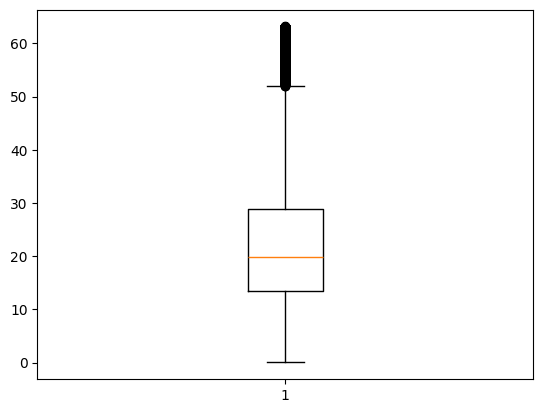

In [91]:
plt.boxplot(data['fare_amount'])
plt.show()

## Exploratory Data Analysis

### Fare Amount Distribution by Payment Type
This analysis explores how payment type (Card vs Cash) relates to passenger behavior in terms of fare amount and trip distance. The goal is to understand whether different payment methods show distinct patterns in spending and travel behavior.

To visualize this, we use stacked histograms, which allow us to see:

- The distribution of fare amounts for each payment type
- The distribution of trip distances for each payment type
- How much each payment method contributes within each bin

This helps identify whether one payment type is associated with higher fares or longer trips, which is useful for understanding customer behavior and revenue patterns.

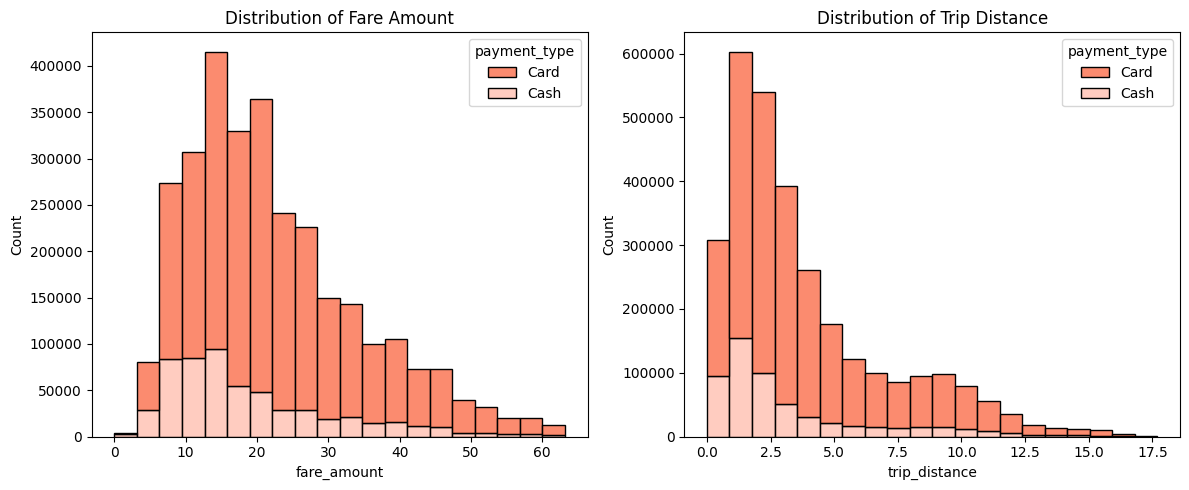

In [95]:
plt.figure(figsize=(12,5))

# Fare Amount Distribution

plt.subplot(1,2,1)

sns.histplot(
    data=data,
    x='fare_amount',
    hue='payment_type',
    multiple='stack',
    bins=20,
    edgecolor='k',
    palette={'Card': '#FA643F', 'Cash': '#FFBCAB'}
)

plt.title('Distribution of Fare Amount')


# Trip Distance Distribution

plt.subplot(1,2,2)

sns.histplot(
    data=data,
    x='trip_distance',
    hue='payment_type',
    multiple='stack',
    bins=20,
    edgecolor='k',
    palette={'Card': '#FA643F', 'Cash': '#FFBCAB'}
)

plt.title('Distribution of Trip Distance')

plt.tight_layout()
plt.show()

In [99]:
data.groupby('payment_type').agg({'fare_amount' : ['mean', 'std'], 'trip_distance' : ['mean','std']})

fare_amount            trip_distance          
                    mean        std          mean       std
payment_type                                               
Card           22.948031  11.869369      4.012282  3.226797
Cash           18.964880  11.741327      3.224963  3.105018

- Card payments are associated with higher average fares and longer trip distances compared to cash payments. 
- The standard deviations for both fare and distance are very similar across payment types, indicating comparable variability within each group. This suggests that the difference in means is not driven by differences in dispersion.
- These observed differences indicate a potential association between payment type and trip characteristics. However, to determine whether this difference is statistically significant, a formal two-sample (Welch’s) t-test is required.

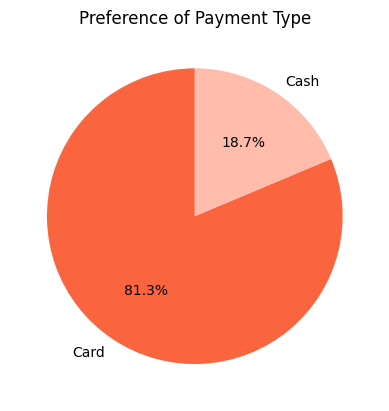

In [108]:
plt.title('Preference of Payment Type')

plt.pie(
    data['payment_type'].value_counts(normalize=True),
    labels=data['payment_type'].value_counts().index,
    startangle=90,
    autopct='%1.1f%%',
    colors=['#FA643F', '#FFBCAB']
)

plt.show()

passenger_count,1,2,3,4,5
payment_type,,,,,
Card,1775540,441361,128632,80742,20209
Cash,421072,94888,23833,18488,3210


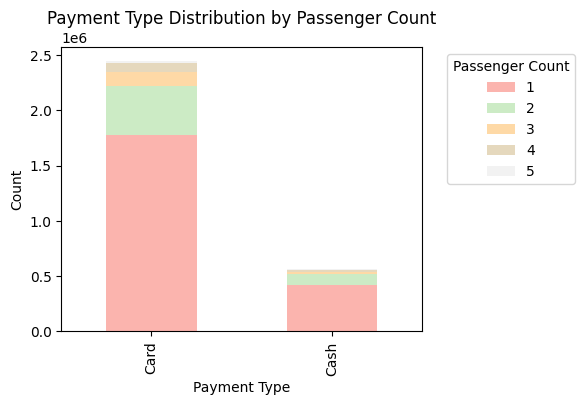

In [119]:
# Create a frequency table
temp = pd.crosstab(data['payment_type'], data['passenger_count'])

display(temp)

# Plot stacked bar chart
ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4),
    colormap='Pastel1'
)

plt.title('Payment Type Distribution by Passenger Count')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.legend(title='Passenger Count', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### Key insights:

- Single-passenger rides (1 passenger) contribute the highest number of transactions for both payment methods. -
- Card payments are overwhelmingly preferred, suggesting customers favor digital payment convenience.
- As passenger count increases, the number of trips gradually decreases for both payment types.
- Passenger counts of 4 and 5 represent only a very small share of total rides.
- The distribution pattern is similar for both payment methods, but the volume gap between Card and Cash is substantial.

### Average Fare by Payment Type

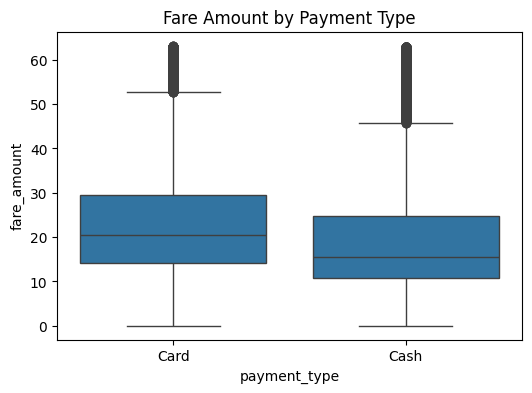

In [124]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=data,
    x='payment_type',
    y='fare_amount'
)

plt.title("Fare Amount by Payment Type")

plt.show()

#### Data for A/B